In [17]:
using Oceananigans
using CairoMakie
using CairoMakie.Colors
using Statistics

include("../src-fig/figures/preinitial_conditions.jl")
include("../src-simulation/parameters.jl")
include("../src-simulation/base_state.jl")
include("../src-simulation/grid_faces.jl")

include("../src-fig/plotting.jl")
include("front.jl")

cumulative_avg_b (generic function with 1 method)

In [29]:
Cs = ["1_0", "1_4", "1_8", "2_0", "2_2", "2_6", "3_0"]
αs = ["0_10"]
run_ids = ["a$α-b1_0-C$C" for C in Cs, α in αs][:]
foldernames = [joinpath("../../scratch/turbulence-at-many-fronts", run_id) for run_id in run_ids]

7-element Vector{String}:
 "../../scratch/turbulence-at-many-fronts/a0_10-b1_0-C1_0"
 "../../scratch/turbulence-at-many-fronts/a0_10-b1_0-C1_4"
 "../../scratch/turbulence-at-many-fronts/a0_10-b1_0-C1_8"
 "../../scratch/turbulence-at-many-fronts/a0_10-b1_0-C2_0"
 "../../scratch/turbulence-at-many-fronts/a0_10-b1_0-C2_2"
 "../../scratch/turbulence-at-many-fronts/a0_10-b1_0-C2_6"
 "../../scratch/turbulence-at-many-fronts/a0_10-b1_0-C3_0"

In [30]:
# Center
bs_surface = map(foldernames) do foldername
    COARSE = joinpath(foldername, "COARSE.jld2")
    sp = simulation_parameters(COARSE)
    avg_buoyancy(COARSE, -0.15sp.H, -0.05sp.H)
end
bs_center = map(foldernames) do foldername
    COARSE = joinpath(foldername, "COARSE.jld2")
    sp = simulation_parameters(COARSE)
    avg_buoyancy(COARSE, -0.95sp.H, -0.05sp.H)
end;

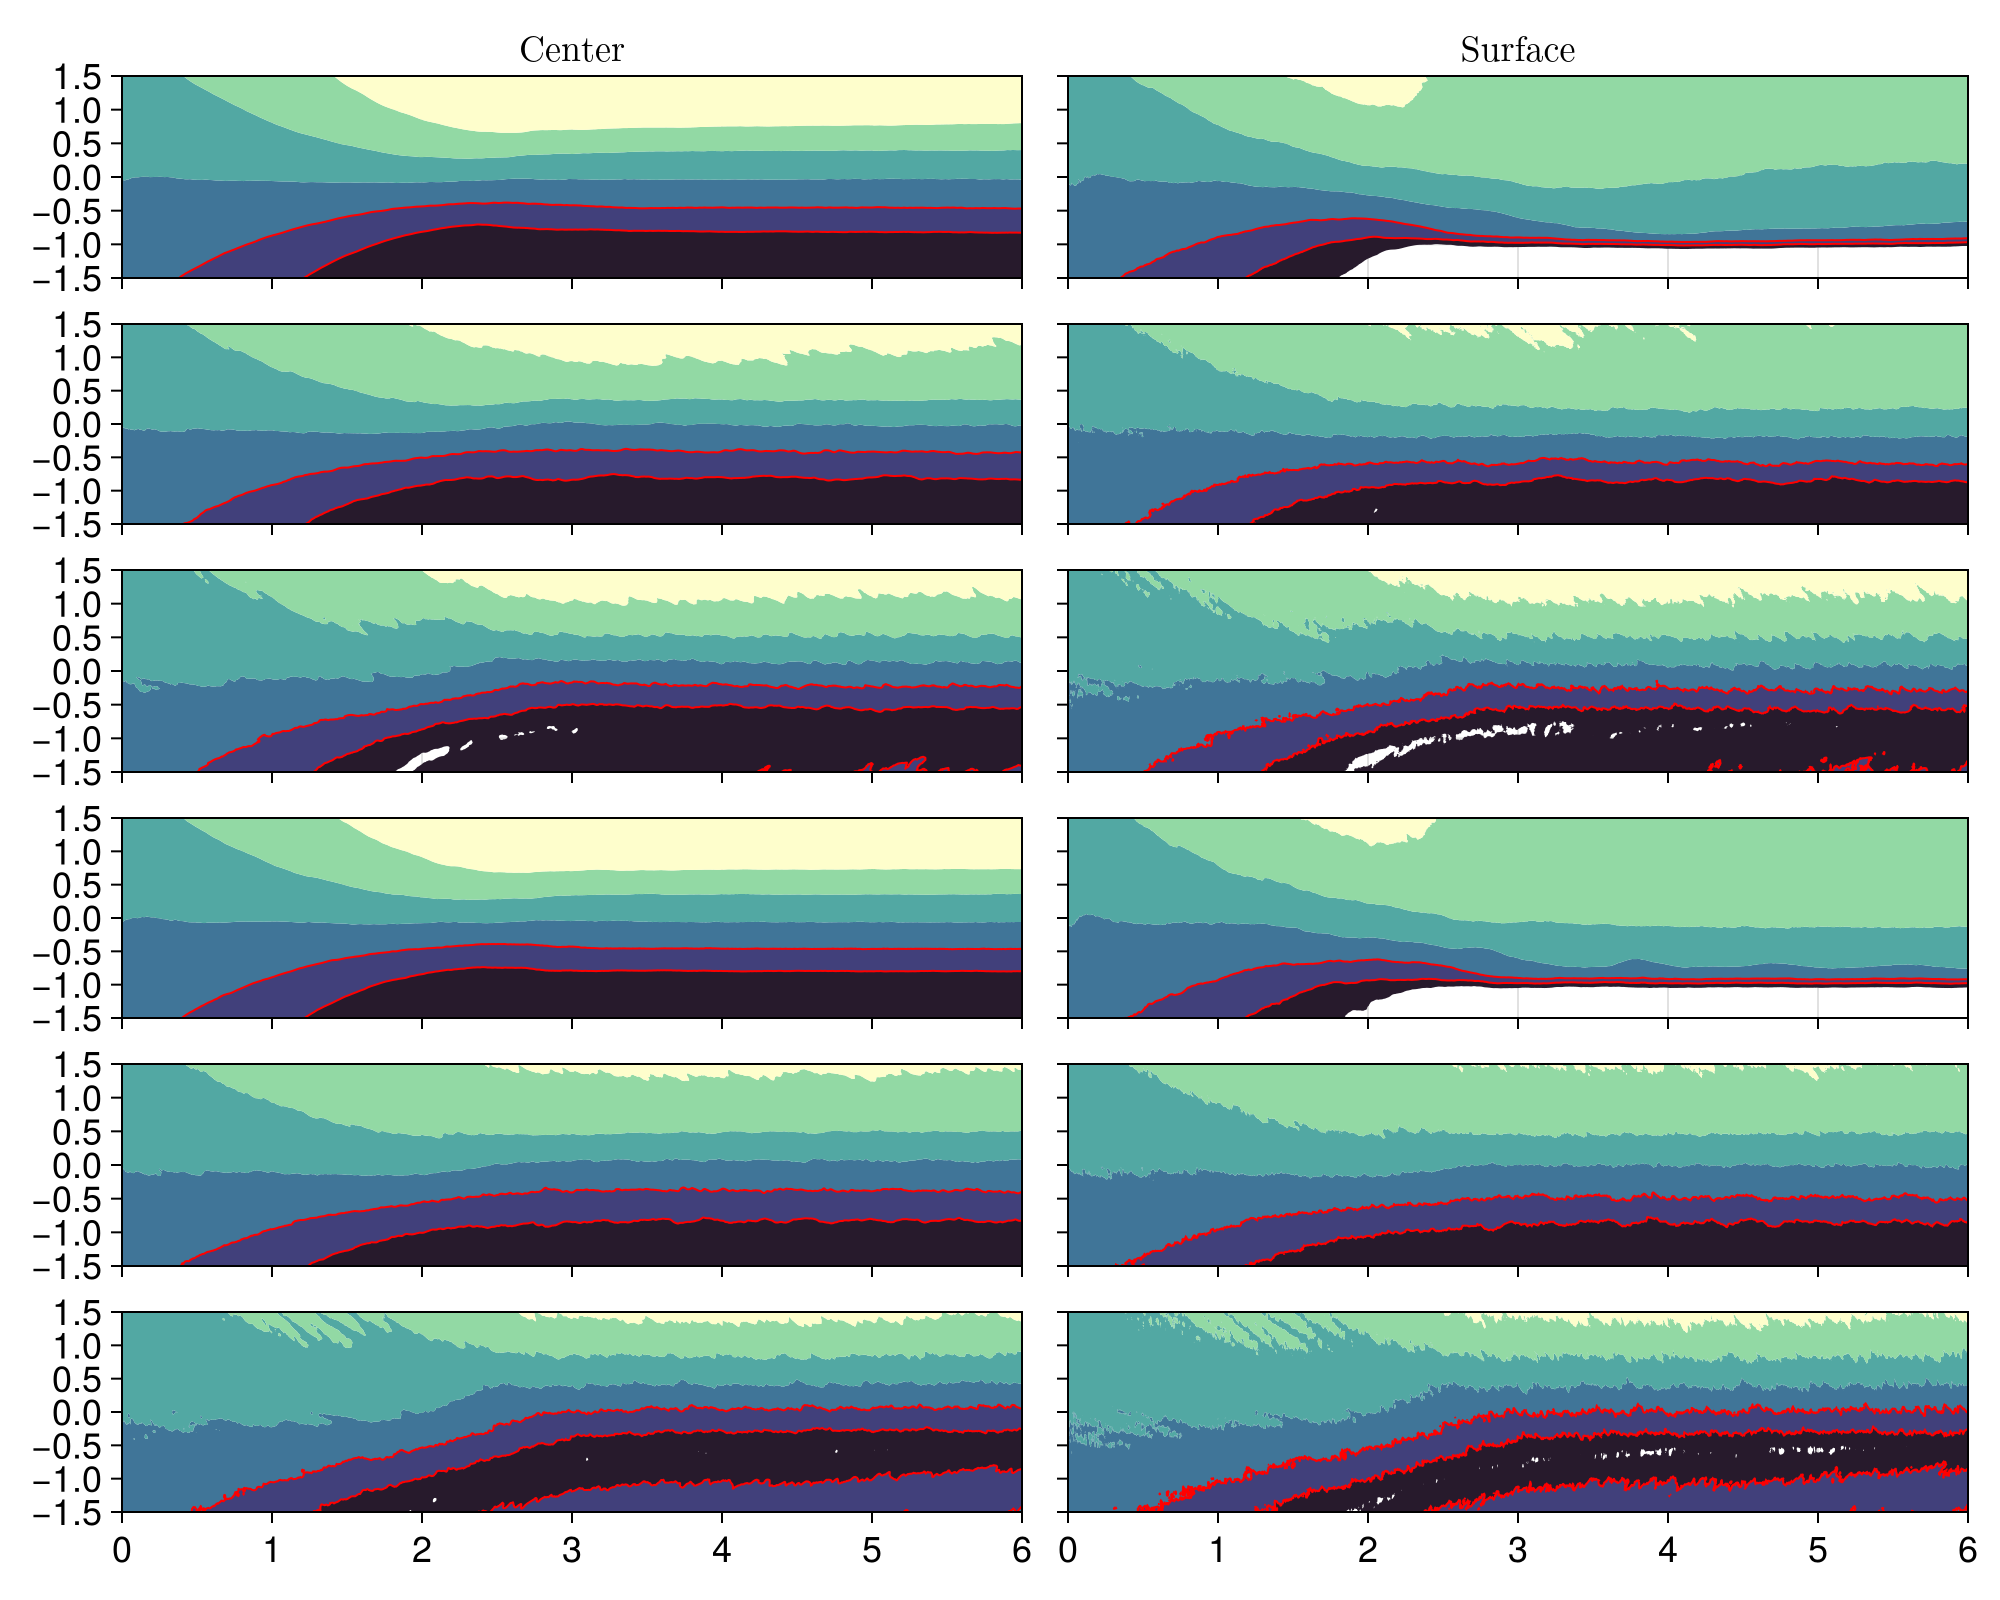

In [5]:
fig = Figure(; size=(1000, 800), fontsize=18)
for i in axes(foldernames, 1)
    DFM = joinpath(foldernames[i], "COARSE.jld2")
    
    iterations, times = iterations_times(DFM)
    sp = simulation_parameters(DFM)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(DFM)
    inds = center_indices(DFM)
    ∫αdt = normalized_time(DFM)
    
    levels = (-0.5):(1 / 6):(0.5)
    colormap = reverse(to_colormap(:deep))
    
    bl = -2 / 6
    br = -1 / 6
    
    ax = Axis(fig[i, 1];
        limits = (0, 6, -sp.Lh / 2000, sp.Lh / 2000),
        title = i == 1 ? L"\text{Center}" : ""
    )
    i < length(foldernames) && hidexdecorations!(ax; ticks=false, grid=false)

    
    
    b = (bs_center[i] .- mean(bs_center[i]; dims=2)) ./ sp.Δb
    
    contourf!(ax, ∫αdt, xsᶜ ./ 1000, b; colormap, levels)
    contour!(ax, ∫αdt, xsᶜ ./ 1000, b; color=:red, levels = [bl])
    contour!(ax, ∫αdt, xsᶜ ./ 1000, b; color=:red, levels = [br])

    ax = Axis(fig[i, 2];
        limits = (0, 6, -sp.Lh / 2000, sp.Lh / 2000),
        title = i == 1 ? L"\text{Surface}" : ""
    )
    i < length(foldernames) && hidexdecorations!(ax; ticks=false, grid=false)
    hideydecorations!(ax; ticks=false, grid=false)
    
    b = (bs_surface[i] .- mean(bs_surface[i]; dims=2)) ./ sp.Δb
    
    contourf!(ax, ∫αdt, xsᶜ ./ 1000, b; colormap, levels)
    contour!(ax, ∫αdt, xsᶜ ./ 1000, b; color=:red, levels = [bl])
    contour!(ax, ∫αdt, xsᶜ ./ 1000, b; color=:red, levels = [br])
    
end
fig

# Width
For a fixed mixed layer depth, the frontogenesis rate and width of the averaged front at arrest is not sensitive to cooling strength. As the front gets smaller, the ageostropic secondary circulation strengthens. If the cooling isn't too strong, the front enters a restratifying phase. The surface width is held as isopycnals tilt and a portion of the front restratifies. Then the frontogenesis continues at seemingly the same rate. 
**Not only does mixing not enhance frontal growth rate, but it suppresses the super-exponential growth in all but the weakest case**

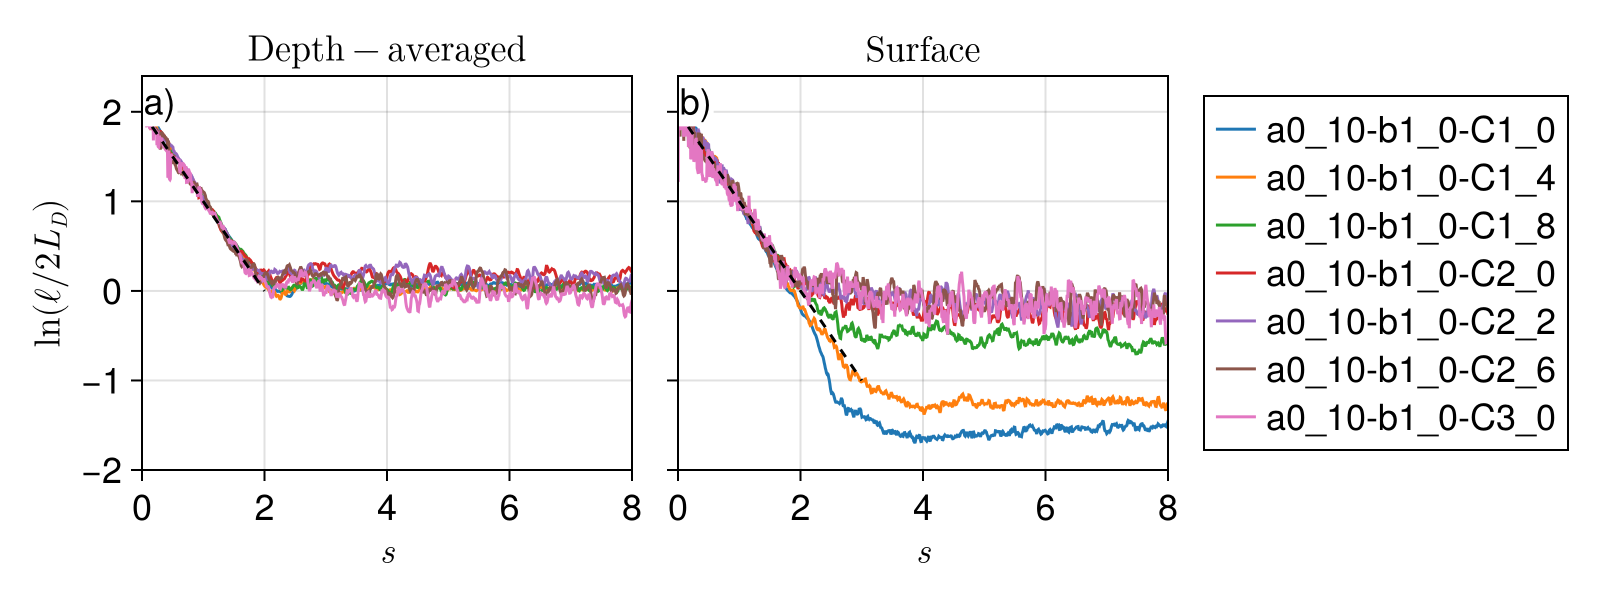

In [32]:
fig = Figure(; size=(800, 300), fontsize=18)
ax = Axis(fig[1, 1];
    xlabel = L"s",
    ylabel = L"\ln(\ell / 2L_D)",
    title = L"\text{Depth-averaged}",
    limits = (0, 8, -2, 2.4)
)
ax_surface = Axis(fig[1, 2];
    xlabel = L"s",
    ylabel = L"\ln(\ell / 2L_D)",
    title = L"\text{Surface}",
    limits = (0, 8, -2, 2.4)
)
hideydecorations!(ax_surface; ticks=false, grid=false)

colors = to_colormap(:tab10)

lns = map(1:length(foldernames)) do i 
    COARSE = joinpath(foldernames[i], "COARSE.jld2")
    
    iterations, times = iterations_times(COARSE)
    sp = simulation_parameters(COARSE)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(COARSE)
    inds = center_indices(COARSE)
    ∫αdt = normalized_time(COARSE)

    C = @sprintf "%02.1f" :C in keys(sp) ? sp.C : sp.Ek
    
    bl = -2 / 6
    br = bl + 1 / 6
    
    b = (bs_center[i] .- mean(bs_center[i]; dims=2)) ./ sp.Δb
    ilr_center, xlr_center, ℓ_center = front_width(COARSE, b, bl, br)

    b = (bs_surface[i] .- mean(bs_surface[i]; dims=2)) ./ sp.Δb
    ilr_surface, xlr_surface, ℓ_surface = front_width(COARSE, b, bl, br)
    
    lines!(ax, ∫αdt, log.(6ℓ_center ./ 2sp.L); color=colors[i])
    lines!(ax_surface, ∫αdt, log.(6ℓ_surface./ 2sp.L); color=colors[i], label=L"%$C")
end
lines!(ax, range(0, 2), x->2-x; color=:black, linestyle=:dash)

lines!(ax_surface, range(0, 3), x->2-x; color=:black, linestyle=:dash)

subfig_label!(fig[1, 1], 1; fontsize=18)
subfig_label!(fig[1, 2], 2; fontsize=18)

Legend(fig[1, 3], lns, run_ids)
fig

# Energetics
Cooling provides a source of potential energy. The energy fluxes from the mean kinetic and potential energies of the front averaged over the central region

In [117]:
VSPs = map(foldernames) do foldername
    TKE = joinpath(foldername, "TKE-L.jld2")
    sp = simulation_parameters(TKE)
    iterations, times = iterations_times(TKE)
    inds = center_indices(TKE)
    
    k1, k2 = zᶜbounds(TKE, -0.85sp.H, -0.15sp.H)
    avg_func(field) = mean(field[inds, k1:k2])
    
    timeseries_of(avg_func, TKE, "vsp", iterations)
end

BFLUXs = map(foldernames) do foldername
    TKE = joinpath(foldername, "TKE-L.jld2")
    sp = simulation_parameters(TKE)
    iterations, times = iterations_times(TKE)
    inds = center_indices(TKE)
    
    k1, k2 = zᶜbounds(TKE, -0.85sp.H, -0.15sp.H)
    avg_func(field) = mean(field[inds, k1:k2])
    
    timeseries_of(avg_func, TKE, "bflux", iterations)
end;

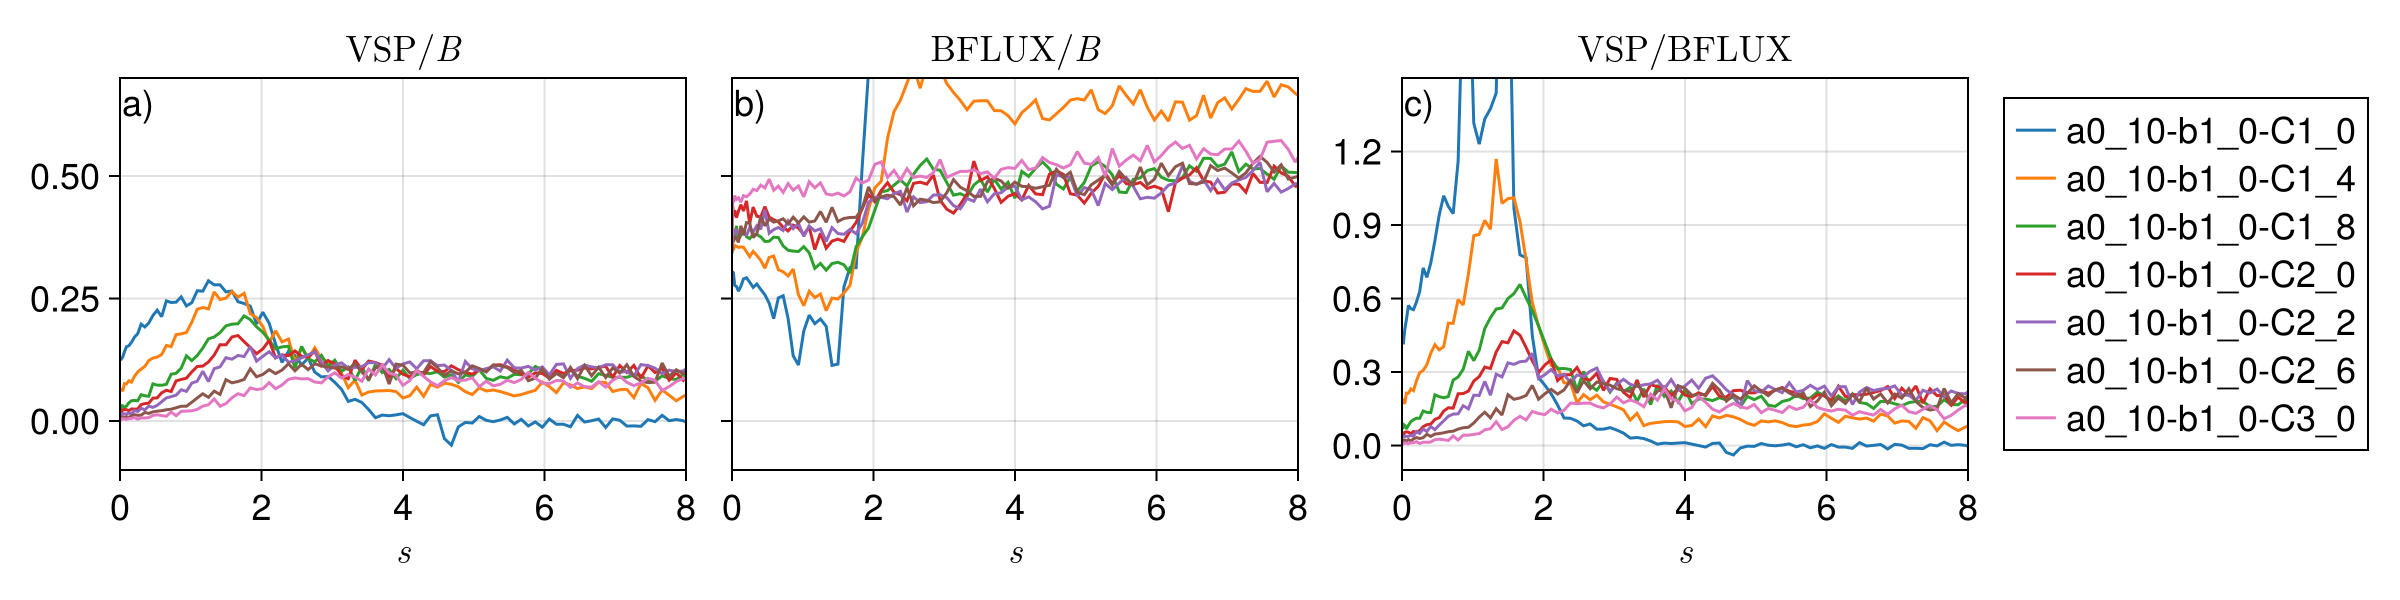

In [118]:
fig = Figure(; size=(1200, 300), fontsize=18)
ax_VSP = Axis(fig[1, 1];
    xlabel = L"s",
    title = L"\text{VSP} / B",
    limits = (0, 8, -0.1, 0.7)
)

ax_BFLUX = Axis(fig[1, 2];
    xlabel = L"s",
    title = L"\text{BFLUX} / B",
    limits = (0, 8, -0.1, 0.7)
)
hideydecorations!(ax_BFLUX; ticks=false, grid=false)

ax_eff = Axis(fig[1, 3];
    xlabel = L"s",
    title = L"\text{VSP} / \text{BFLUX}",
    limits = (0, 8, -0.1, 1.5)
)
#hideydecorations!(ax_eff; ticks=false, grid=false)

colors = to_colormap(:tab10)

lns = map(1:length(foldernames)) do i 
    TKE = joinpath(foldernames[i], "TKE.jld2")
    
    iterations, times = iterations_times(TKE)
    sp = simulation_parameters(TKE)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(TKE)
    inds = center_indices(TKE)
    ∫αdt = normalized_time(TKE)

    C = @sprintf "%02.1f" sp.C
    
    VSP = VSPs[i] ./ sp.B
    BFLUX = BFLUXs[i] ./ sp.B
    
    lines!(ax_VSP, ∫αdt, VSP; color=colors[i])
    lines!(ax_BFLUX, ∫αdt, BFLUX; color=colors[i])
    lines!(ax_eff, ∫αdt, VSP ./ BFLUX; color=colors[i])
end

subfig_label!(fig[1, 1], 1; fontsize=18)
subfig_label!(fig[1, 2], 2; fontsize=18)
subfig_label!(fig[1, 3], 3; fontsize=18)

Legend(fig[1, 4], lns, run_ids[1:end])

fig

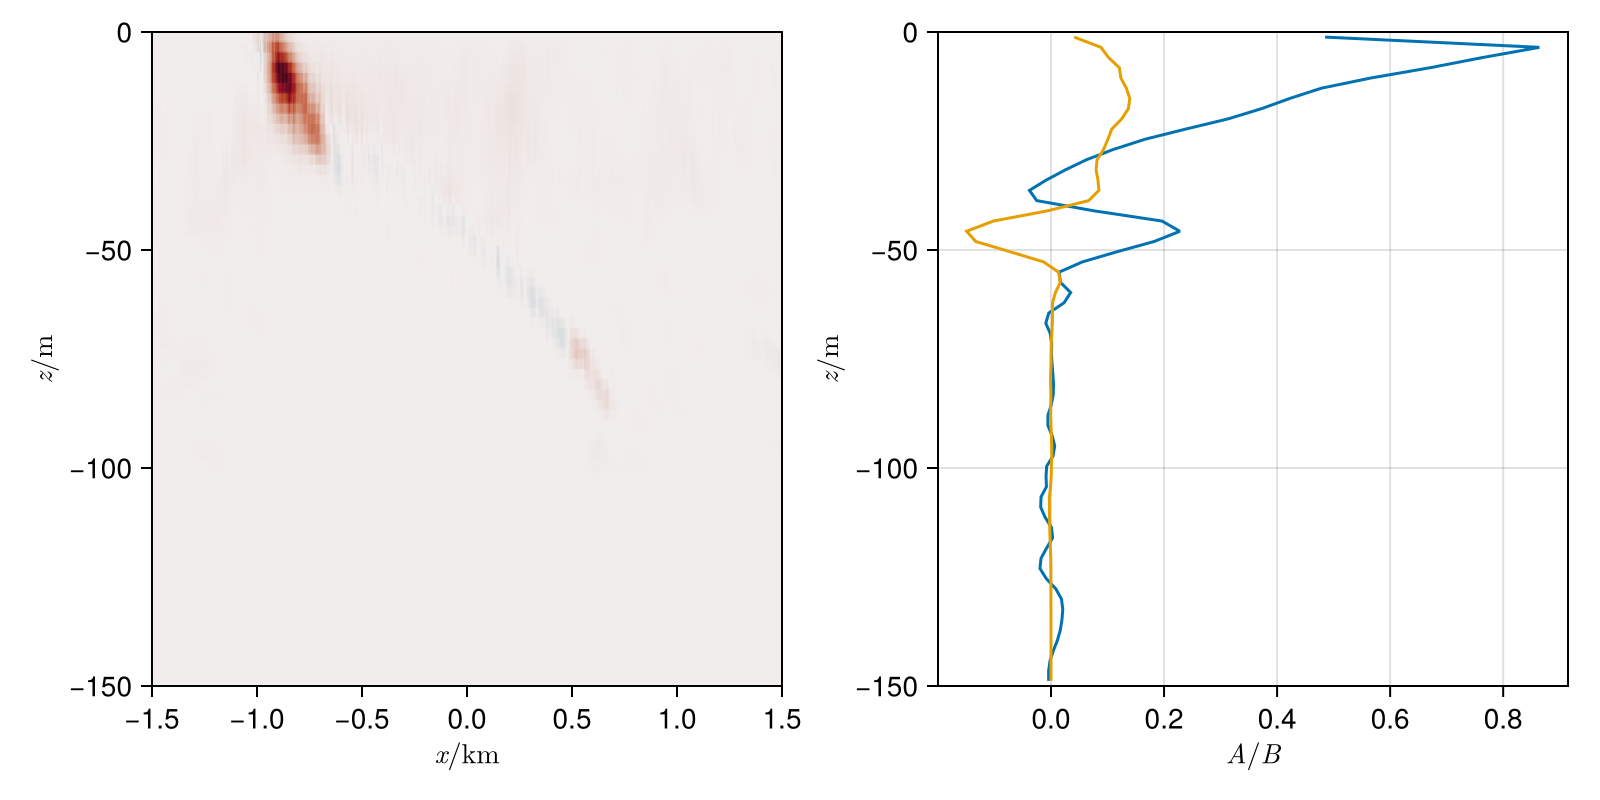

In [145]:
TKE = joinpath(foldernames[1], "TKE.jld2")
sp = simulation_parameters(TKE)
iterations, times = iterations_times(TKE)
xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(TKE)
vsp = get_field(TKE, "vsp", iterations[end]);
bflux = get_field(TKE, "bflux", iterations[end]);

fig = Figure(; size=(800, 400))
ax = Axis(fig[1, 1];
    xlabel = L"x / \text{km}",
    ylabel = L"z / \text{m}",
    limits = (-sp.Lh/2000, sp.Lh/2000, -sp.Lz, 0)
)
#η = vsp ./ bflux
colorrange = (-maximum(abs, vsp), maximum(abs, vsp))
#colorrange = (-10, 10)
heatmap!(ax, xsᶜ ./ 1000, zsᶜ, vsp; colorrange, colormap=:balance)

ax = Axis(fig[1, 2];
    xlabel = L"A / B",
    ylabel = L"z / \text{m}",
    limits = (nothing, nothing, -sp.Lz, 0)
)
x = 
lines!(ax, mean(bflux[500:524, :]; dims=1)[1, :] ./ sp.B, zsᶜ)
lines!(ax, mean(vsp[500:524, :]; dims=1)[1, :] ./ sp.B, zsᶜ)
fig

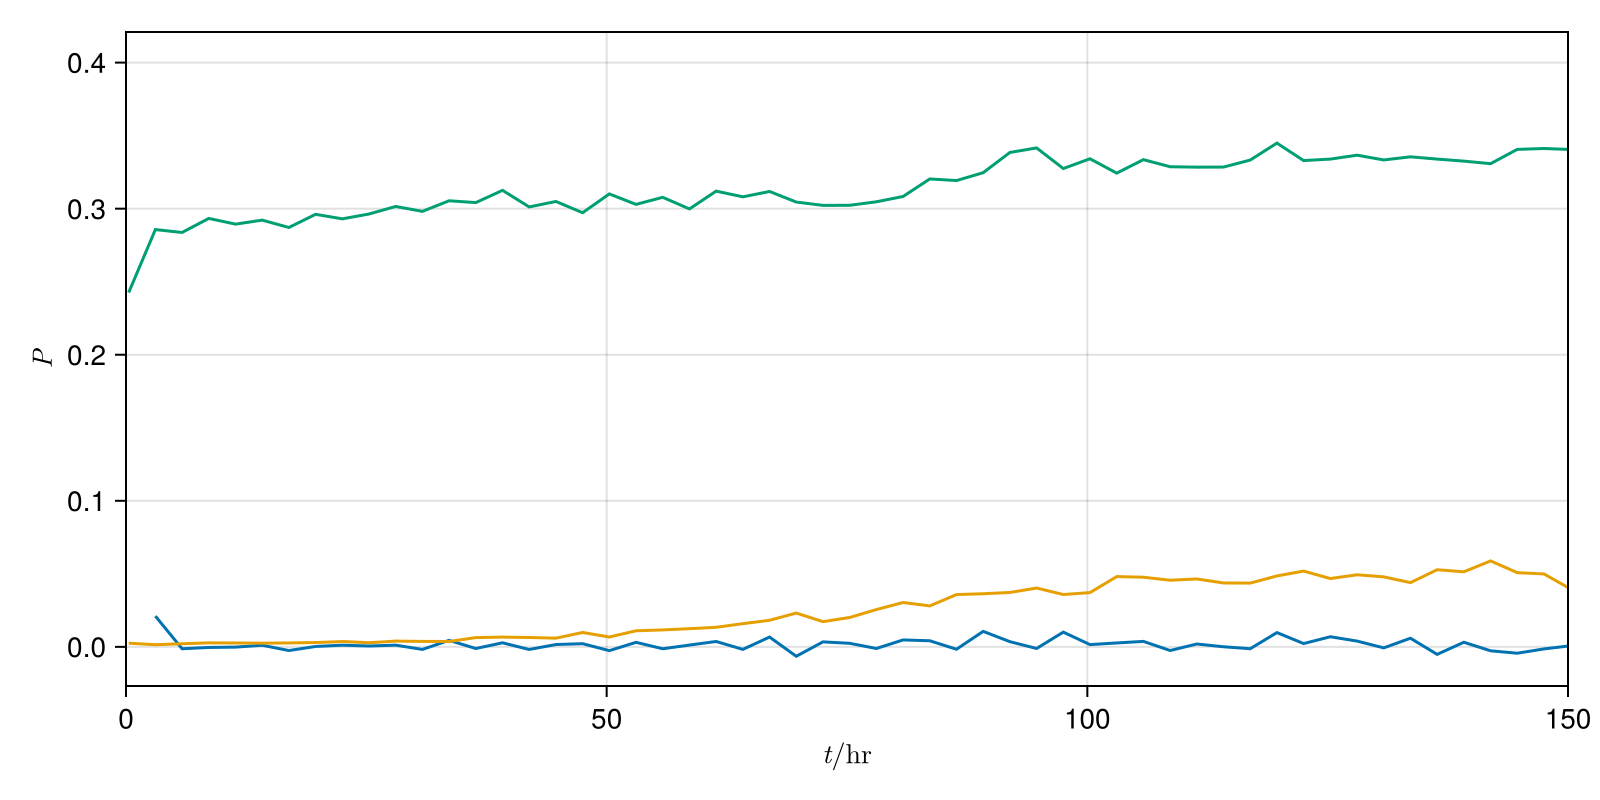

In [167]:
TKE = joinpath(foldernames[7], "TKE-L.jld2")
sp = simulation_parameters(TKE)
iterations, times = iterations_times(TKE)
xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(TKE)

tke = timeseries_of(mean, TKE, "tke", iterations)
vsp = timeseries_of(mean, TKE, "vsp", iterations)
bflux = timeseries_of(mean, TKE, "bflux", iterations)

fig = Figure(; size=(800, 400))
ax = Axis(fig[1, 1];
    xlabel = L"t / \text{hr}",
    ylabel = L"P",
    limits = (0, 150, nothing, nothing)
)

lines!(ax, times[2:end] ./ 3600, diff(tke) ./ diff(times) ./ sp.B)
lines!(ax, times ./ 3600, vsp ./ sp.B)
lines!(ax, times ./ 3600, bflux ./ sp.B)
fig

In [ ]:
fig = Figure(; size=(800, 400))

ax = Axis(fig[1, 1];
    xlabel = L"t / \text{hr}",
    ylabel = L"\int\text{VSP}",
    limits = (0, 150, nothing, nothing)
)
lines!(ax, times ./ 3600, (times[2] - times[1]) .* cumsum(vsp_timeseries) ./ ΔE)

ax = Axis(fig[1, 2];
    xlabel = L"t / \text{hr}",
    ylabel = L"\text{VSP} / ΔE \, \text{day}^{-1}",
    limits = (0, 150, nothing, nothing)
)
lines!(ax, times ./ 3600, vsp_timeseries ./ ΔE .* Δt)


fig

In [148]:
u = get_field(v->v.^2 / 2, joinpath(foldername, "DFM.jld2"), "u_dfm", iterations[21])
v = get_field(v->v.^2 / 2, joinpath(foldername, "DFM.jld2"), "v_dfm", iterations[21])
w = get_field(v->v.^2 / 2, joinpath(foldername, "DFM.jld2"), "w_dfm", iterations[21])
tke = get_field(joinpath(foldername, "TKE.jld2"), "TKE", iterations[21])

ΔE = sum(u) + sum(v) + sum(w) + sum(tke)

LoadError: UndefVarError: `foldername` not defined